In [164]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

In [165]:
df = pd.read_csv("cust_data.csv")
df.head()
print(df.shape)
print(df.info())
print(df.isnull().sum())

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


In [166]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Encode target column
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop customer ID
df = df.drop("customerID", axis=1)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [167]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [168]:
categorical_columns = X_train.select_dtypes(include="object").columns
numerical_columns = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')


C:\Users\omkar\AppData\Local\Temp\ipykernel_7568\4054950456.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include="object").columns


In [169]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(), categorical_columns)
    ]
)

In [170]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 45)
(1409, 45)


In [171]:
lr_model = LogisticRegression()

lr_model.fit(X_train_processed, y_train)

lr_pred = lr_model.predict(X_test_processed)

In [172]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))

Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647


In [173]:
cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[926 109]
 [165 209]]


In [174]:
y_prob = lr_model.predict_proba(X_test_processed)[:, 1]
lr_pred_03 = (y_prob >= 0.3).astype(int)

In [175]:
print("Accuracy:", accuracy_score(y_test, lr_pred_03))
print("Precision:", precision_score(y_test, lr_pred_03))
print("Recall:", recall_score(y_test, lr_pred_03))

Accuracy: 0.7494677075940384
Precision: 0.5193370165745856
Recall: 0.7540106951871658


In [176]:
cv_scores = cross_val_score(
    lr_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="recall"
)

print("Recall Scores:", cv_scores)
print("Average Recall:", cv_scores.mean())

Recall Scores: [0.59197324 0.52508361 0.54180602 0.53846154 0.54180602]
Average Recall: 0.5478260869565218


In [177]:
# Trying Decision Trees because of the feature combination possibility
tree = DecisionTreeClassifier(max_depth=6, random_state=42)

tree.fit(X_train_processed, y_train)

tree_pred = tree.predict(X_test_processed)

In [178]:
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))

Accuracy: 0.7913413768630234
Precision: 0.6342281879194631
Recall: 0.5053475935828877


In [179]:
print("Train:", tree.score(X_train_processed, y_train))
print("Test:", tree.score(X_test_processed, y_test))

Train: 0.8104366347177849
Test: 0.7913413768630234


In [180]:
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))

Accuracy: 0.7913413768630234
Precision: 0.6342281879194631
Recall: 0.5053475935828877


In [181]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_processed, y_train)

rf_pred = rf.predict(X_test_processed)

In [182]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))

Accuracy: 0.7778566359119943
Precision: 0.6033898305084746
Recall: 0.47593582887700536


In [183]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 10, 12, 15]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

Best Parameters: {'max_depth': 12, 'n_estimators': 300}
Best CV Recall: 0.5123745819397993


In [184]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test_processed)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))

Accuracy: 0.7970191625266146
Precision: 0.6476510067114094
Recall: 0.516042780748663


In [185]:
importance_df = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
1,num__tenure,0.138209
3,num__TotalCharges,0.134785
2,num__MonthlyCharges,0.106687
36,cat__Contract_Month-to-month,0.077098
18,cat__OnlineSecurity_No,0.042896
16,cat__InternetService_Fiber optic,0.036336
43,cat__PaymentMethod_Electronic check,0.035334
27,cat__TechSupport_No,0.033481
38,cat__Contract_Two year,0.023517
21,cat__OnlineBackup_No,0.018520


<Axes: ylabel='Feature'>

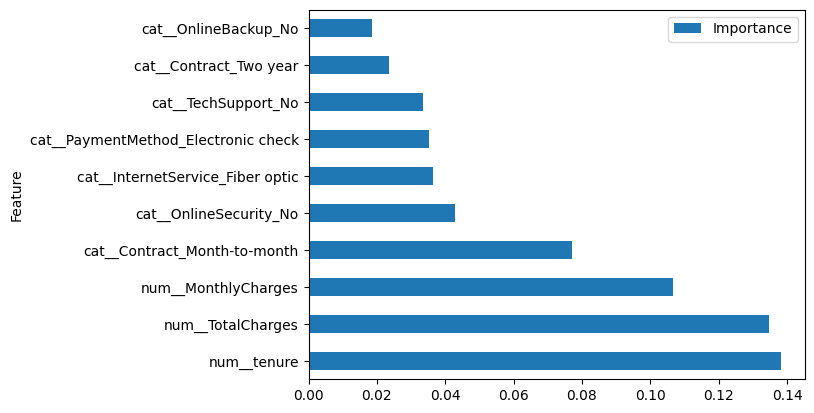

In [186]:
importance_df.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

# Conclusion

- Logistic Regression achieved the best overall performance on this dataset.
- Lowering the classification threshold improved recall and helped identify more potential churners.
- Decision Trees captured non-linear relationships but showed signs of overfitting.
- Random Forest performance improved after hyperparameter tuning but did not outperform Logistic Regression.
- Tenure, TotalCharges, MonthlyCharges, and Contract Type were among the most important factors influencing churn.